In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Set2')

COUNTRY = 'Tanzania'
DATA_PATH = '../data/tanzania.csv'
CLEAN_PATH = '../data/tanzania_clean.csv'

print(f'Analysis target: {COUNTRY}')

Analysis target: Tanzania


In [32]:
# Load CSV
df = pd.read_csv(DATA_PATH, comment='#')
print(f'Shape: {df.shape}')
df.head()

Shape: (4108, 12)


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,27.56,29.52,26.22,3.30,7.24,80.97,4.68,6.01,100.52,18.61
1,2015,2,27.59,29.99,25.92,4.07,3.40,79.63,4.48,5.28,100.52,18.31
2,2015,3,27.47,29.29,26.25,3.04,7.17,80.02,4.91,5.99,100.56,18.30
3,2015,4,27.28,29.17,25.96,3.21,16.07,81.78,4.88,6.07,100.47,18.52
4,2015,5,26.68,27.83,25.84,1.99,18.83,82.99,4.17,5.98,100.43,18.16


In [33]:
# Add country column
df['Country'] = COUNTRY

# Convert YEAR + DOY to proper datetime
df['Date'] = pd.to_datetime(df['YEAR'] * 1000 + df['DOY'], format='%Y%j')

# Extract Month and Year
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

print('Date range:', df['Date'].min(), '→', df['Date'].max())
print('Total columns:', df.columns.tolist())
df[['Date', 'YEAR', 'DOY', 'Month', 'T2M', 'PRECTOTCORR']].head()

Date range: 2015-01-01 00:00:00 → 2026-03-31 00:00:00
Total columns: ['YEAR', 'DOY', 'T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX', 'PS', 'QV2M', 'Country', 'Date', 'Month', 'Year']


,Date,YEAR,DOY,Month,T2M,PRECTOTCORR
0,2015-01-01,2015,1,1,27.56,7.24
1,2015-01-02,2015,2,1,27.59,3.40
2,2015-01-03,2015,3,1,27.47,7.17
3,2015-01-04,2015,4,1,27.28,16.07
4,2015-01-05,2015,5,1,26.68,18.83


In [34]:
# Replace NASA sentinel value -999 with NaN
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
sentinel_counts = (df[numeric_cols] == -999).sum()

print('Sentinel (-999) counts per column:')
print(sentinel_counts[sentinel_counts > 0])

df[numeric_cols] = df[numeric_cols].replace(-999, np.nan)
print('\n✅ All -999 values replaced with NaN')

Sentinel (-999) counts per column:
Series([], dtype: int64)

✅ All -999 values replaced with NaN


In [35]:
# Check and drop duplicates
n_dupes = df.duplicated().sum()
print(f'Duplicate rows found: {n_dupes}')

if n_dupes > 0:
    df = df.drop_duplicates()
    print(f'Dropped {n_dupes} duplicate rows. New shape: {df.shape}')
else:
    print('No duplicate rows found.')

Duplicate rows found: 0
No duplicate rows found.


In [36]:
# Descriptive statistics
df.describe().round(3)

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month,Year
count,4108.000,4108.000,4108.000,4108.000,4108.000,4108.000,4108.000,4108.000,4108.000,4108.000,4108.000,4108.000,4108,4108.000,4108.000
mean,2020.131,180.121,26.802,29.163,25.038,4.125,3.740,77.128,4.105,5.189,100.801,16.924,2020-08-15 12:00:00,6.424,2020.131
min,2015.000,1.000,22.680,25.410,20.030,0.940,0.000,60.060,1.120,1.550,100.150,11.380,2015-01-01 00:00:00,1.000,2015.000
25%,2017.000,86.000,25.670,28.090,23.710,3.330,0.110,73.168,3.410,4.377,100.570,15.340,2017-10-23 18:00:00,3.000,2017.000
50%,2020.000,179.000,26.990,29.080,25.375,4.220,0.640,76.585,4.190,5.250,100.760,17.220,2020-08-15 12:00:00,6.000,2020.000
75%,2023.000,272.000,27.900,30.170,26.310,4.940,3.790,81.100,4.830,5.980,101.040,18.420,2023-06-08 06:00:00,9.000,2023.000
max,2026.000,366.000,29.970,33.930,28.010,7.590,122.650,91.100,8.400,11.740,101.510,21.510,2026-03-31 00:00:00,12.000,2026.000
std,3.249,106.295,1.325,1.371,1.535,1.103,8.004,5.071,1.060,1.215,0.284,1.882,NaN,3.477,3.249


In [37]:
# Missing value report
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_report = missing_report[missing_report['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print('Missing value report:')
if missing_report.empty:
    print('✅ No missing values found!')
else:
    print(missing_report)
    high_missing = missing_report[missing_report['Missing %'] > 5]
    if not high_missing.empty:
        print(f'\n⚠️ Columns with >5% missing: {high_missing.index.tolist()}')
    else:
        print('\n✅ No column exceeds 5% missing values.')

Missing value report:
✅ No missing values found!


In [38]:
# Z-score outlier detection
outlier_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']
outlier_cols = [c for c in outlier_cols if c in df.columns]

z_scores = df[outlier_cols].apply(lambda x: np.abs(stats.zscore(x, nan_policy='omit')))
outlier_mask = (z_scores > 3).any(axis=1)

print(f'Rows with |Z| > 3 in any column: {outlier_mask.sum()}')
print('\nPer-column outlier counts:')
print((z_scores > 3).sum())

Rows with |Z| > 3 in any column: 97

Per-column outlier counts:
T2M             1
T2M_MAX         2
T2M_MIN         4
PRECTOTCORR    81
RH2M            2
WS2M            8
WS2M_MAX        4
dtype: int64


In [39]:
# Cap WS2M_MAX at 99th percentile (sensor error protection)
cap_val = df['WS2M_MAX'].quantile(0.99)
n_capped = (df['WS2M_MAX'] > cap_val).sum()
df['WS2M_MAX'] = df['WS2M_MAX'].clip(upper=cap_val)
print(f'WS2M_MAX capped at {cap_val:.2f} m/s | {n_capped} rows affected')

# All other outliers retained as real climate signals
print('\nOutlier handling decisions:')
print('  PRECTOTCORR : ✅ Retained — extreme rainfall events are real')
print('  T2M_MIN     : ✅ Retained — cold nights are real climate signals')
print('  RH2M        : ✅ Retained — extreme humidity days are real')
print('  T2M         : ✅ Retained — very few, real temperature signal')
print('  WS2M        : ✅ Retained — very few, real wind signal')
print('  WS2M_MAX    : ⚠️  Capped at 99th percentile — possible sensor error')

WS2M_MAX capped at 7.95 m/s | 42 rows affected

Outlier handling decisions:
  PRECTOTCORR : ✅ Retained — extreme rainfall events are real
  T2M_MIN     : ✅ Retained — cold nights are real climate signals
  RH2M        : ✅ Retained — extreme humidity days are real
  T2M         : ✅ Retained — very few, real temperature signal
  WS2M        : ✅ Retained — very few, real wind signal
  WS2M_MAX    : ⚠️  Capped at 99th percentile — possible sensor error


In [40]:
# Export cleaned data
import os
os.makedirs('../data', exist_ok=True)
df.to_csv(CLEAN_PATH, index=False)
print(f'✅ Cleaned data exported to {CLEAN_PATH}')
print(f'Final shape: {df.shape}')

✅ Cleaned data exported to ../data/tanzania_clean.csv
Final shape: (4108, 16)


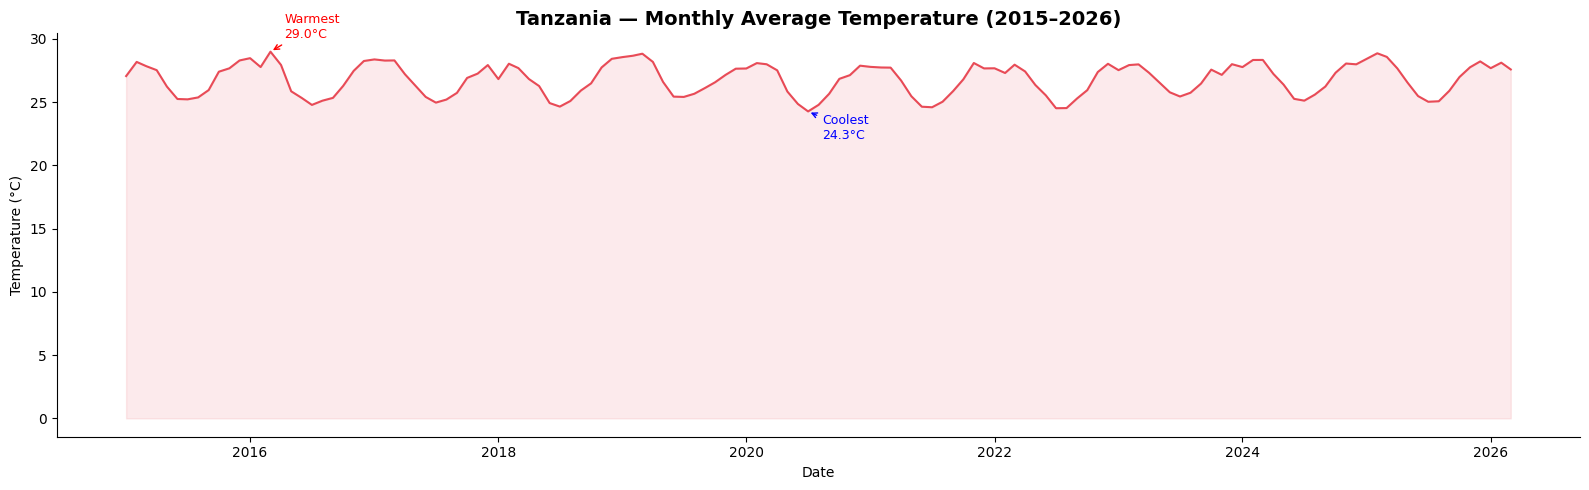

In [41]:
# Monthly average temperature line chart
monthly = df.groupby(df['Date'].dt.to_period('M')).agg(
    T2M=('T2M', 'mean'),
    PRECTOTCORR=('PRECTOTCORR', 'sum')
).reset_index()
monthly['Date'] = monthly['Date'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(monthly['Date'], monthly['T2M'], color='#E63946', linewidth=1.5, alpha=0.9)
ax.fill_between(monthly['Date'], monthly['T2M'], alpha=0.1, color='#E63946')

# Annotate warmest and coolest months
warmest = monthly.loc[monthly['T2M'].idxmax()]
coolest = monthly.loc[monthly['T2M'].idxmin()]

ax.annotate(f"Warmest\n{warmest['T2M']:.1f}°C",
            xy=(warmest['Date'], warmest['T2M']),
            xytext=(10, 10), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color='red'), color='red', fontsize=9)
ax.annotate(f"Coolest\n{coolest['T2M']:.1f}°C",
            xy=(coolest['Date'], coolest['T2M']),
            xytext=(10, -20), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color='blue'), color='blue', fontsize=9)

ax.set_title(f'{COUNTRY} — Monthly Average Temperature (2015–2026)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Temperature (°C)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

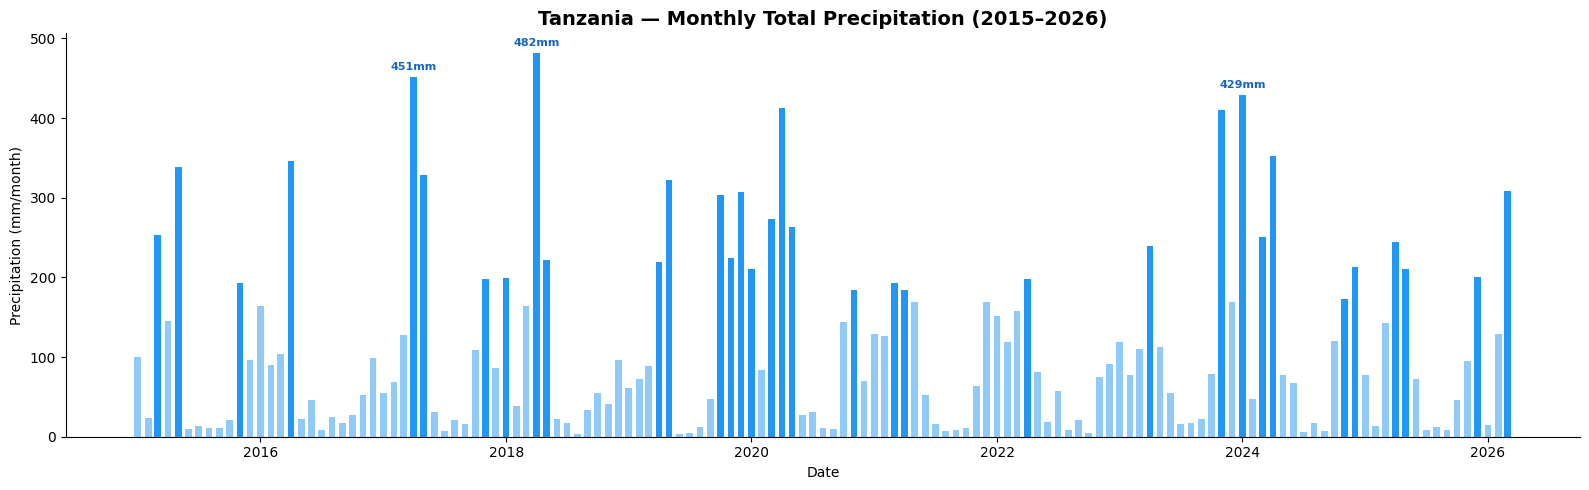

In [42]:
# Monthly total precipitation bar chart
fig, ax = plt.subplots(figsize=(16, 5))
colors = ['#2196F3' if v > monthly['PRECTOTCORR'].quantile(0.75) else '#90CAF9' for v in monthly['PRECTOTCORR']]
ax.bar(monthly['Date'], monthly['PRECTOTCORR'], color=colors, width=20)

# Annotate peak months
peak = monthly.nlargest(3, 'PRECTOTCORR')
for _, row in peak.iterrows():
    ax.annotate(f"{row['PRECTOTCORR']:.0f}mm",
                xy=(row['Date'], row['PRECTOTCORR']),
                xytext=(0, 5), textcoords='offset points',
                ha='center', fontsize=8, color='#1565C0', fontweight='bold')

ax.set_title(f'{COUNTRY} — Monthly Total Precipitation (2015–2026)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Precipitation (mm/month)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

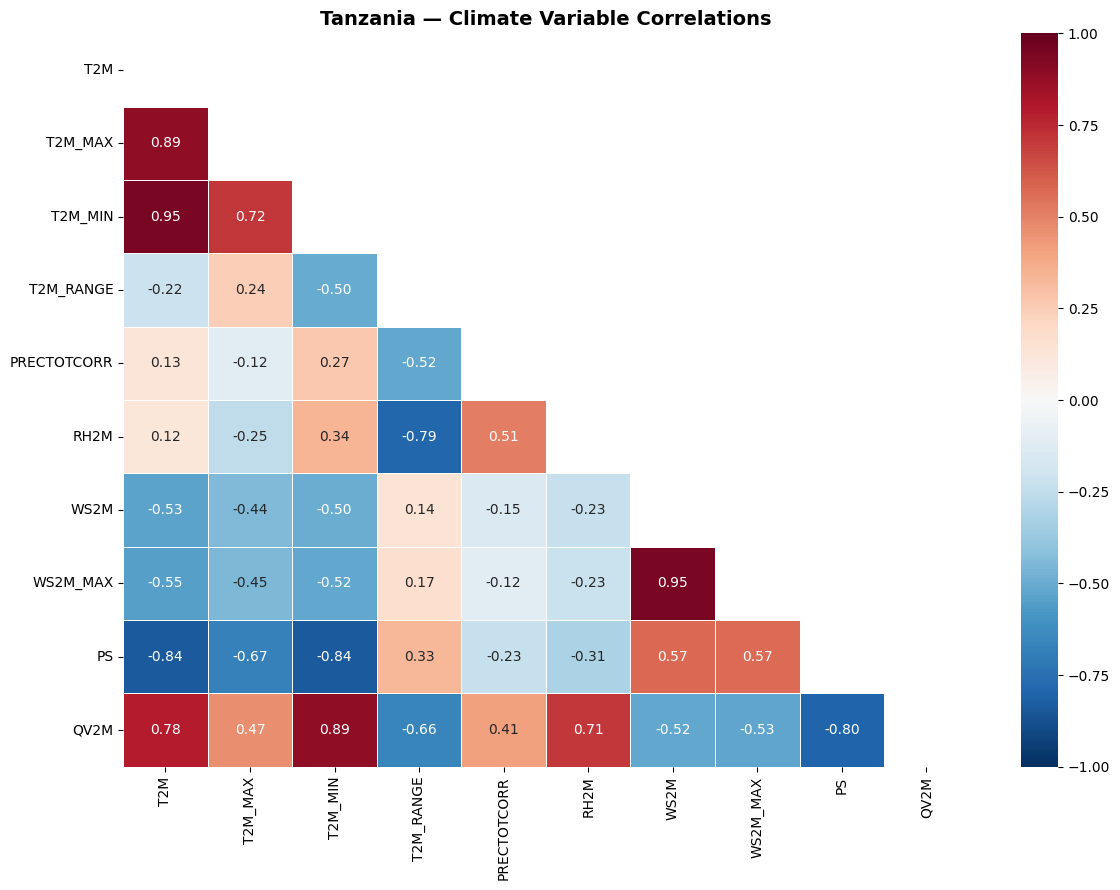

In [43]:
# Correlation heatmap
corr_cols = [c for c in ['T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE',
             'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX', 'PS', 'QV2M'] if c in df.columns]

corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax,
            annot_kws={'size': 10}, linewidths=0.5)
ax.set_title(f'{COUNTRY} — Climate Variable Correlations', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

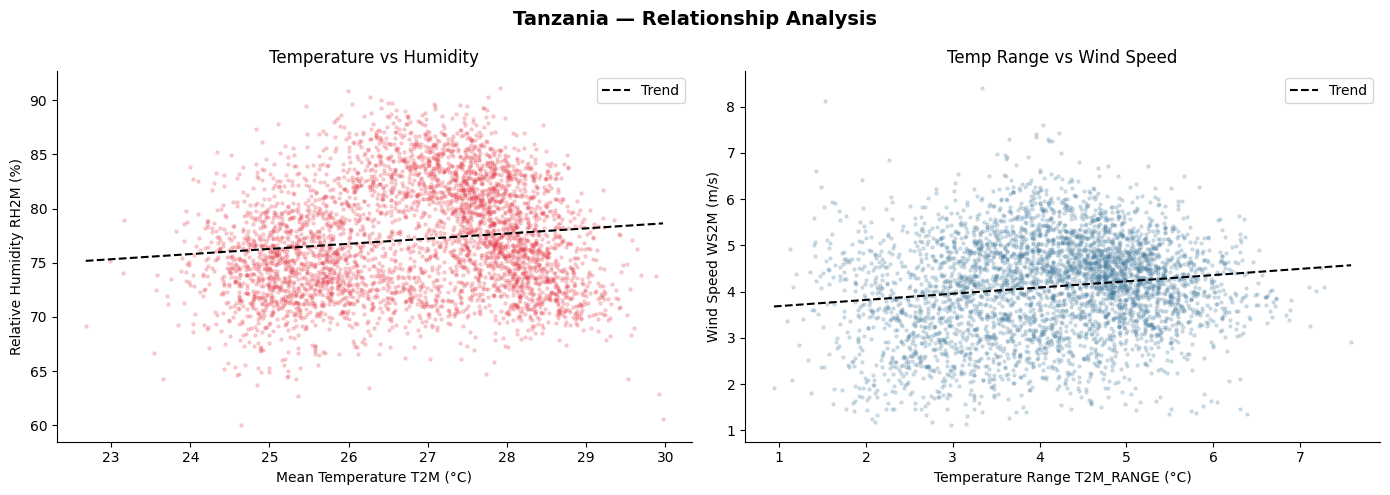

In [44]:
# Scatter plots: T2M vs RH2M and T2M_RANGE vs WS2M
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# T2M vs RH2M
axes[0].scatter(df['T2M'], df['RH2M'], alpha=0.2, s=5, color='#E63946')
z = np.polyfit(df['T2M'].dropna(), df['RH2M'].dropna(), 1)
p = np.poly1d(z)
x_line = np.linspace(df['T2M'].min(), df['T2M'].max(), 200)
axes[0].plot(x_line, p(x_line), 'k--', linewidth=1.5, label='Trend')
axes[0].set_xlabel('Mean Temperature T2M (°C)')
axes[0].set_ylabel('Relative Humidity RH2M (%)')
axes[0].set_title('Temperature vs Humidity')
axes[0].legend()

# T2M_RANGE vs WS2M
axes[1].scatter(df['T2M_RANGE'], df['WS2M'], alpha=0.2, s=5, color='#457B9D')
z2 = np.polyfit(df['T2M_RANGE'].dropna(), df['WS2M'].dropna(), 1)
p2 = np.poly1d(z2)
x_line2 = np.linspace(df['T2M_RANGE'].min(), df['T2M_RANGE'].max(), 200)
axes[1].plot(x_line2, p2(x_line2), 'k--', linewidth=1.5, label='Trend')
axes[1].set_xlabel('Temperature Range T2M_RANGE (°C)')
axes[1].set_ylabel('Wind Speed WS2M (m/s)')
axes[1].set_title('Temp Range vs Wind Speed')
axes[1].legend()

plt.suptitle(f'{COUNTRY} — Relationship Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

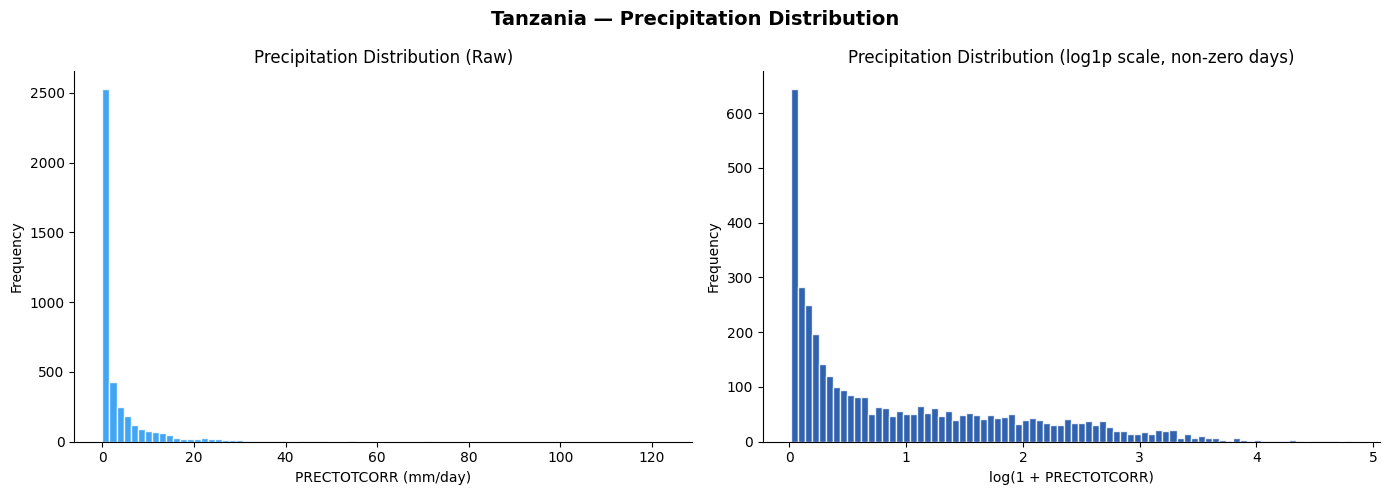

Zero-rain days: 213 (5.2%)
Skewness: 5.25


In [45]:
# Precipitation histogram
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw distribution
axes[0].hist(df['PRECTOTCORR'].dropna(), bins=80, color='#2196F3', edgecolor='white', alpha=0.85)
axes[0].set_title('Precipitation Distribution (Raw)')
axes[0].set_xlabel('PRECTOTCORR (mm/day)')
axes[0].set_ylabel('Frequency')

# Log scale
precip_nonzero = df['PRECTOTCORR'][df['PRECTOTCORR'] > 0].dropna()
axes[1].hist(np.log1p(precip_nonzero), bins=80, color='#0D47A1', edgecolor='white', alpha=0.85)
axes[1].set_title('Precipitation Distribution (log1p scale, non-zero days)')
axes[1].set_xlabel('log(1 + PRECTOTCORR)')
axes[1].set_ylabel('Frequency')

plt.suptitle(f'{COUNTRY} — Precipitation Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Zero-rain days: {(df["PRECTOTCORR"] == 0).sum()} ({(df["PRECTOTCORR"] == 0).mean()*100:.1f}%)')
print(f'Skewness: {df["PRECTOTCORR"].skew():.2f}')

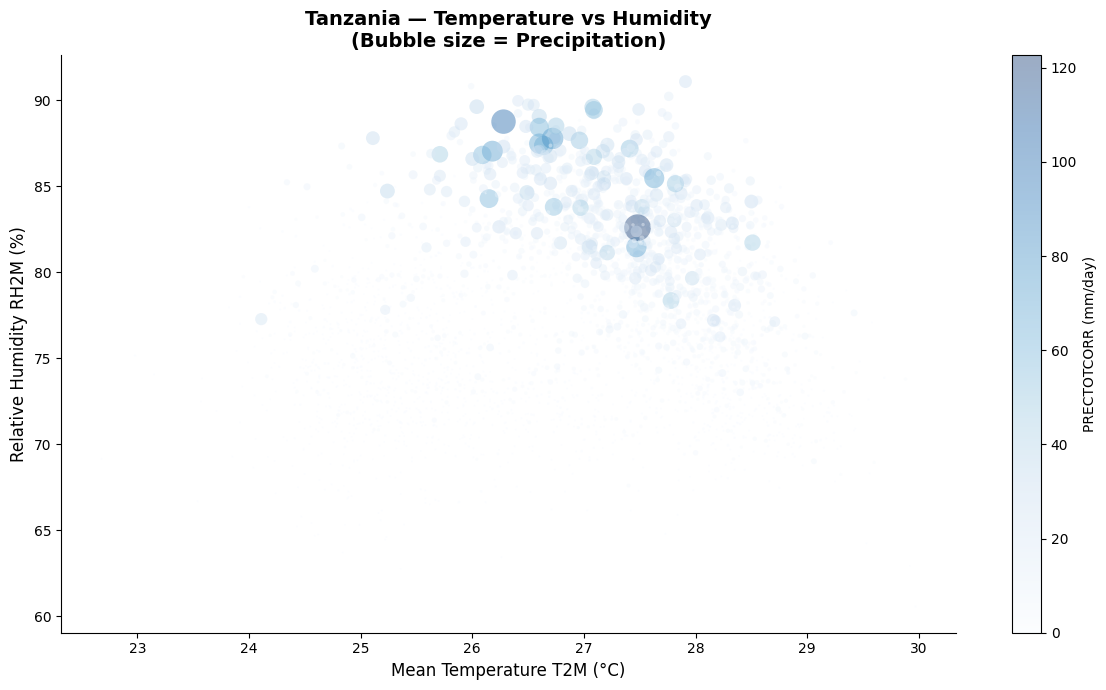

In [46]:
# Bubble chart: T2M vs RH2M, bubble size = PRECTOTCORR
sample = df.dropna(subset=['T2M', 'RH2M', 'PRECTOTCORR']).sample(min(3000, len(df)), random_state=42)
bubble_size = (sample['PRECTOTCORR'] + 0.5) * 3

fig, ax = plt.subplots(figsize=(12, 7))
sc = ax.scatter(sample['T2M'], sample['RH2M'],
                s=bubble_size, alpha=0.4,
                c=sample['PRECTOTCORR'], cmap='Blues',
                edgecolors='none')
plt.colorbar(sc, ax=ax, label='PRECTOTCORR (mm/day)')
ax.set_xlabel('Mean Temperature T2M (°C)', fontsize=12)
ax.set_ylabel('Relative Humidity RH2M (%)', fontsize=12)
ax.set_title(f'{COUNTRY} — Temperature vs Humidity\n(Bubble size = Precipitation)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()